Comprobamos que tenemos GPU



In [2]:
!nvidia-smi

Tue Nov 11 10:09:00 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   55C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

Instalamos las librerias del proyecto

In [3]:
!pip install ultralytics
!pip install roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 60.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 94.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 100.3 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.12.0.88
    Uninstalling opencv-python-headless-4.12.0.88:
      Successfully uninstalled opencv-python-headless-4.12.0.88
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11


Cargamos de roboflow el dataset de rostros con emociones

In [ ]:
import ultralytics
from ultralytics import YOLO
from IPython.display import Image
from roboflow import Roboflow

rf = Roboflow(api_key="api_key") # API KEY de Roboflow -> https://app.roboflow.com/
project = rf.workspace("workenv-dayet").project("facial-emotion-dataset-7g1jd-hipbk")
version = project.version(3)
dataset = version.download("yolov11")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Facial-Emotion-Dataset--3 in yolov11:: 100%|██████████| 2466/2466 [00:00<00:00, 6605.63it/s]


Ejecutamos el modelo Yolo11 con las imagenes cargadas de roboflow

Nos descargamos el modelo

Ahora solo queda probar si el modelo funciona correctamente en un entorno real con la camara se realiza en el otro notebook

In [ ]:
!yolo task=detect mode=train model=yolo11m.pt data={dataset.location}/data.yaml \
epochs=300 patience=50 imgsz=640 \
augment=True mosaic=1.0 copy_paste=0.5 mixup=0.3 erasing=0.5 fliplr=0.7 \
hsv_h=0.05 hsv_s=0.8 hsv_v=0.5 scale=0.7

Ultralytics 8.3.227 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.5, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Facial-Emotion-Dataset--3/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=300, erasing=0.5, exist_ok=False, fliplr=0.7, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.05, hsv_s=0.8, hsv_v=0.5, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.3, mode=train, model=yolo11m.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=50, perspective=0.0, plo

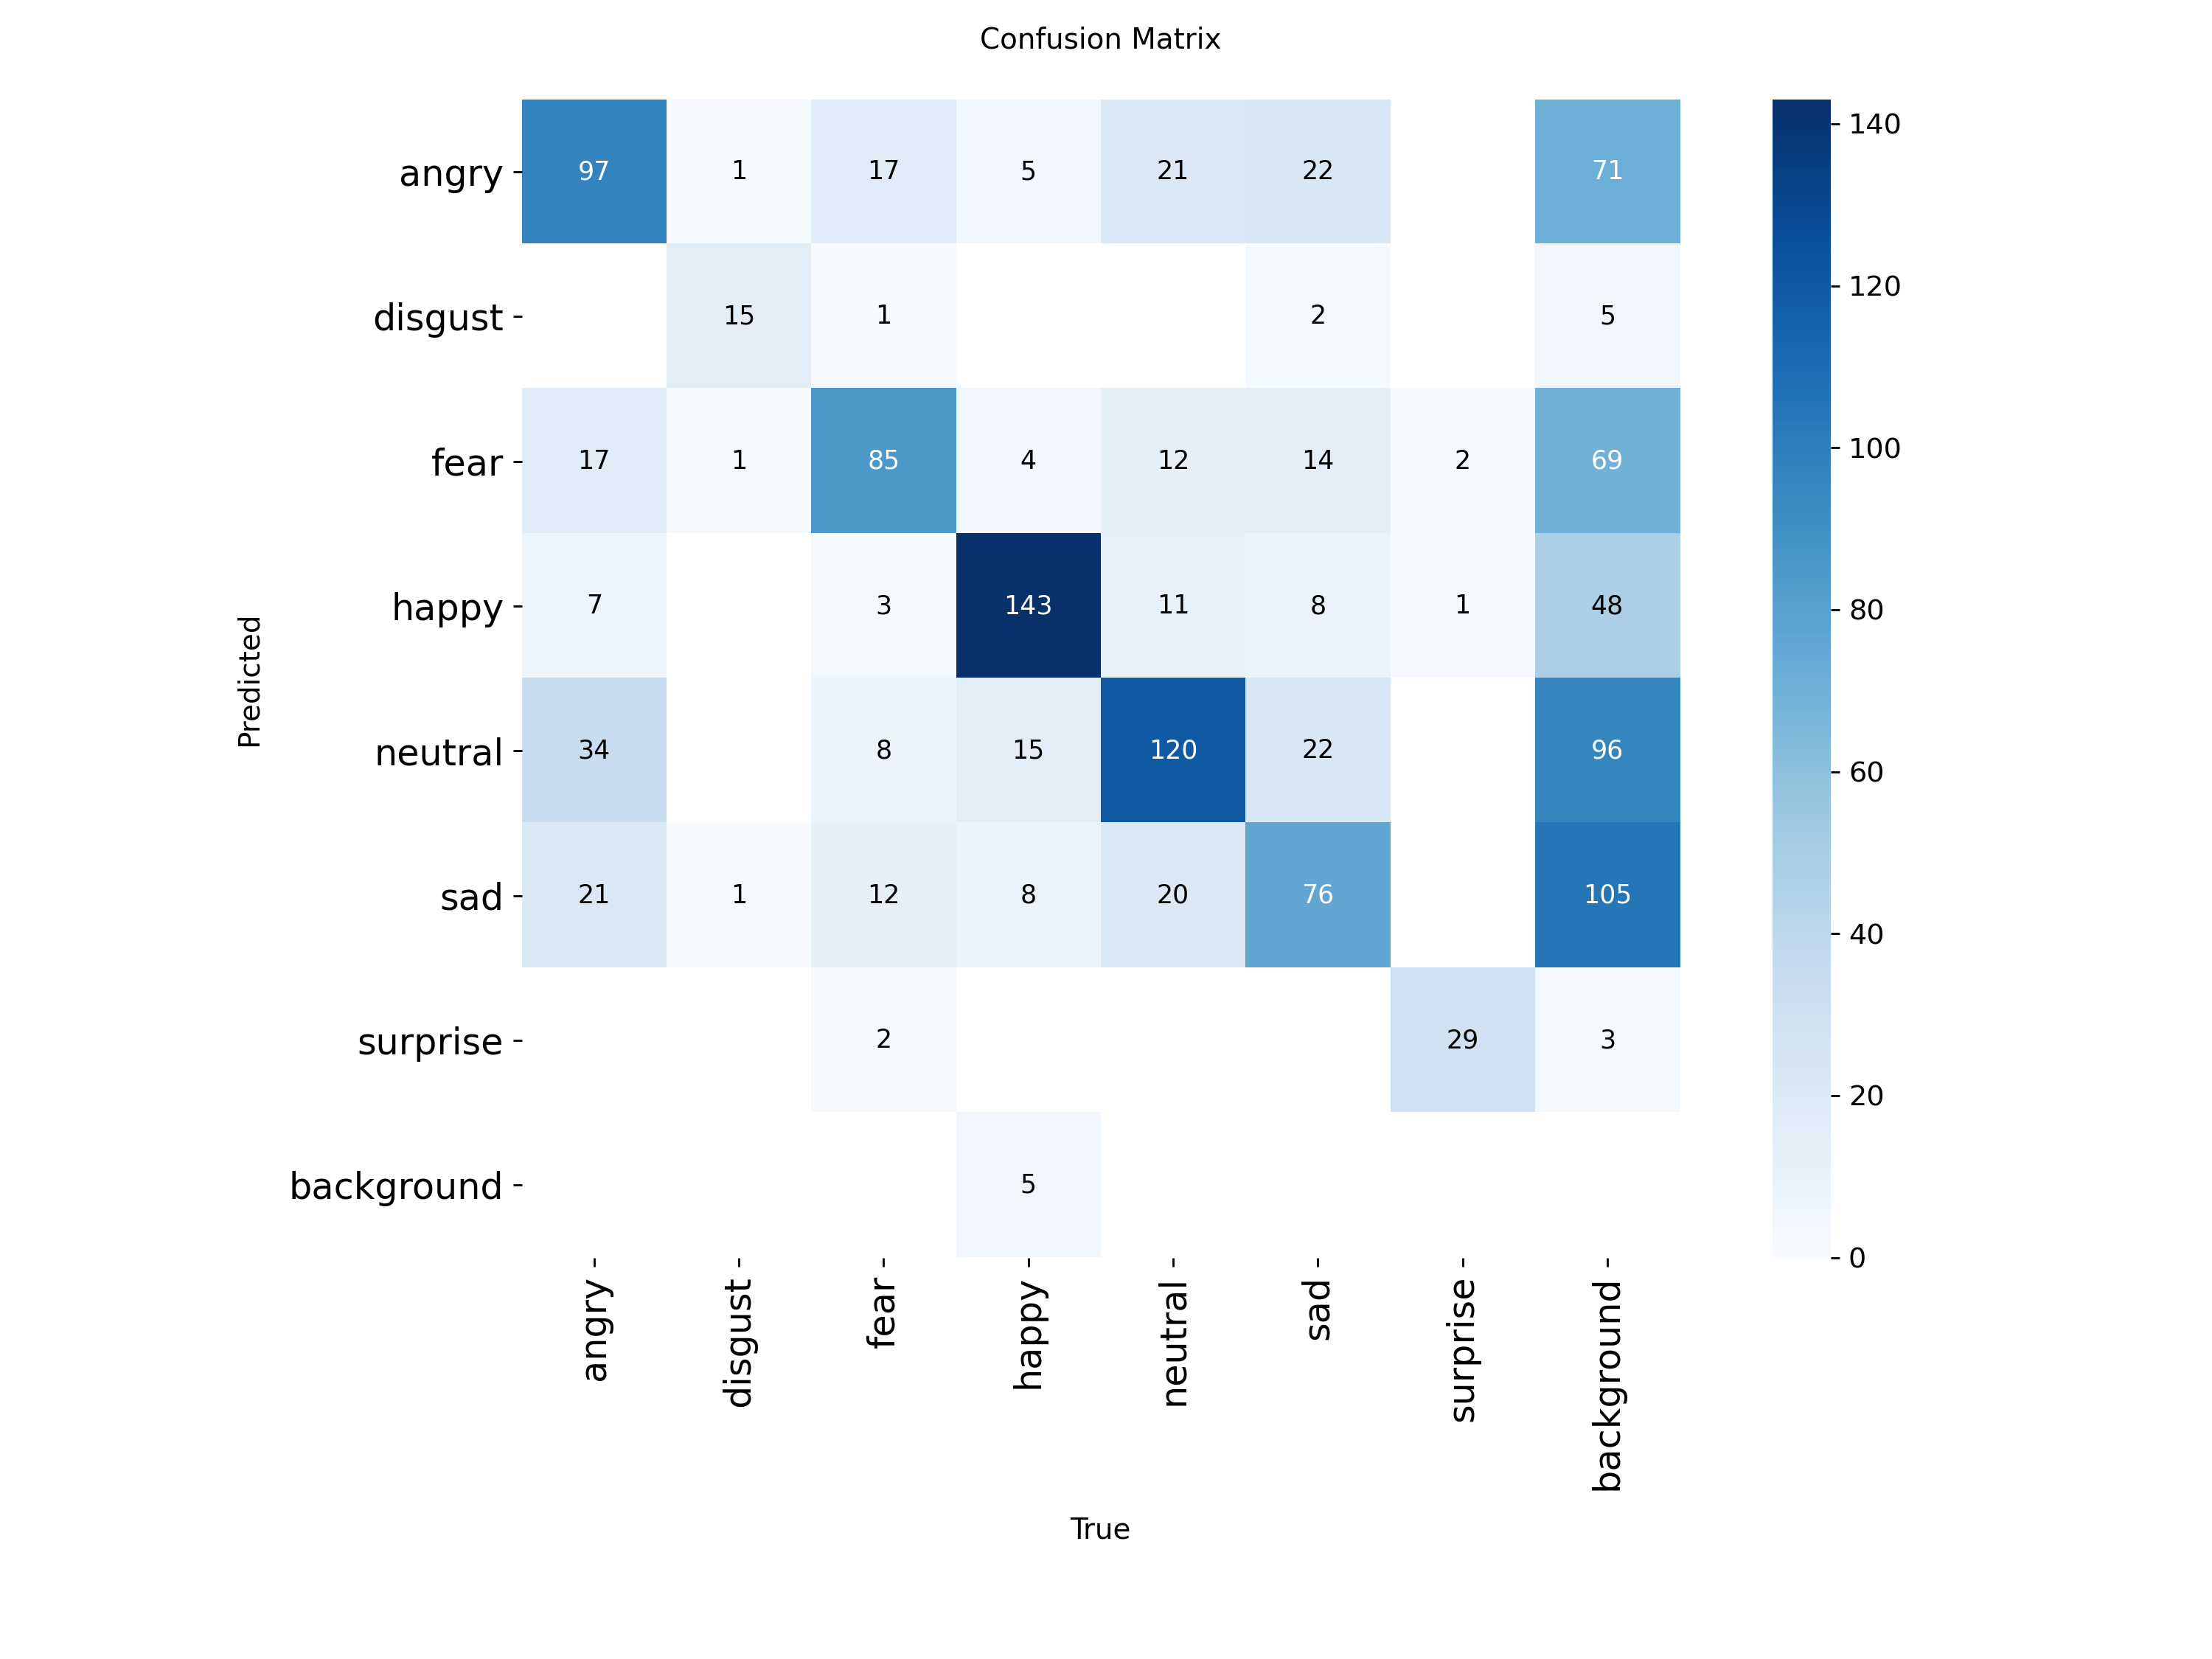

In [11]:
Image("/content/runs/detect/train2/confusion_matrix.png", width="600")

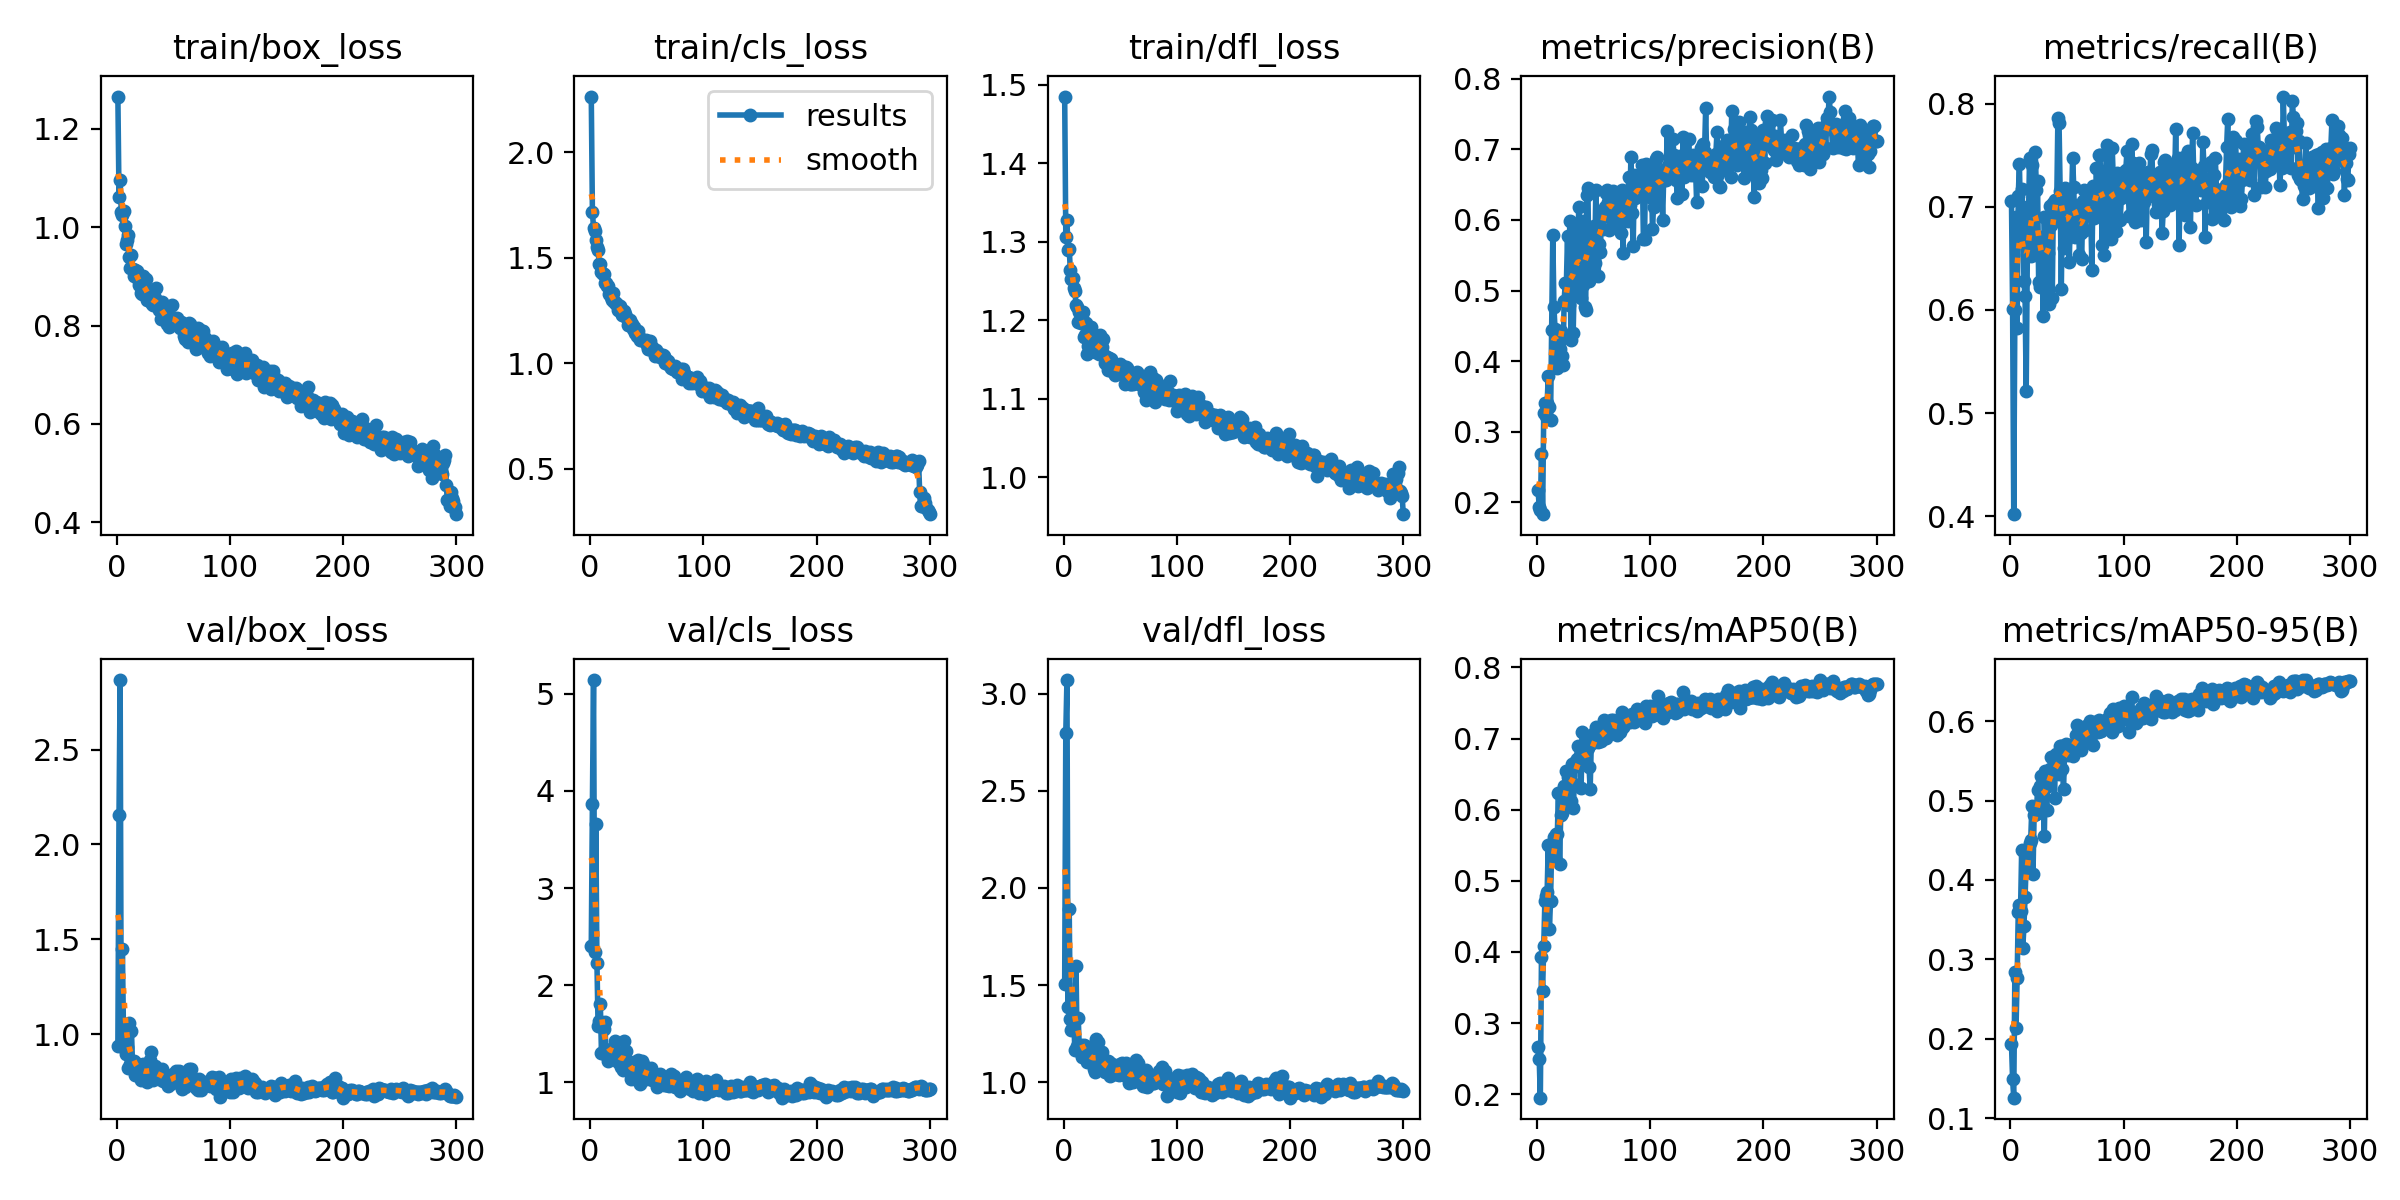

In [12]:
Image("/content/runs/detect/train2/results.png", width="600")

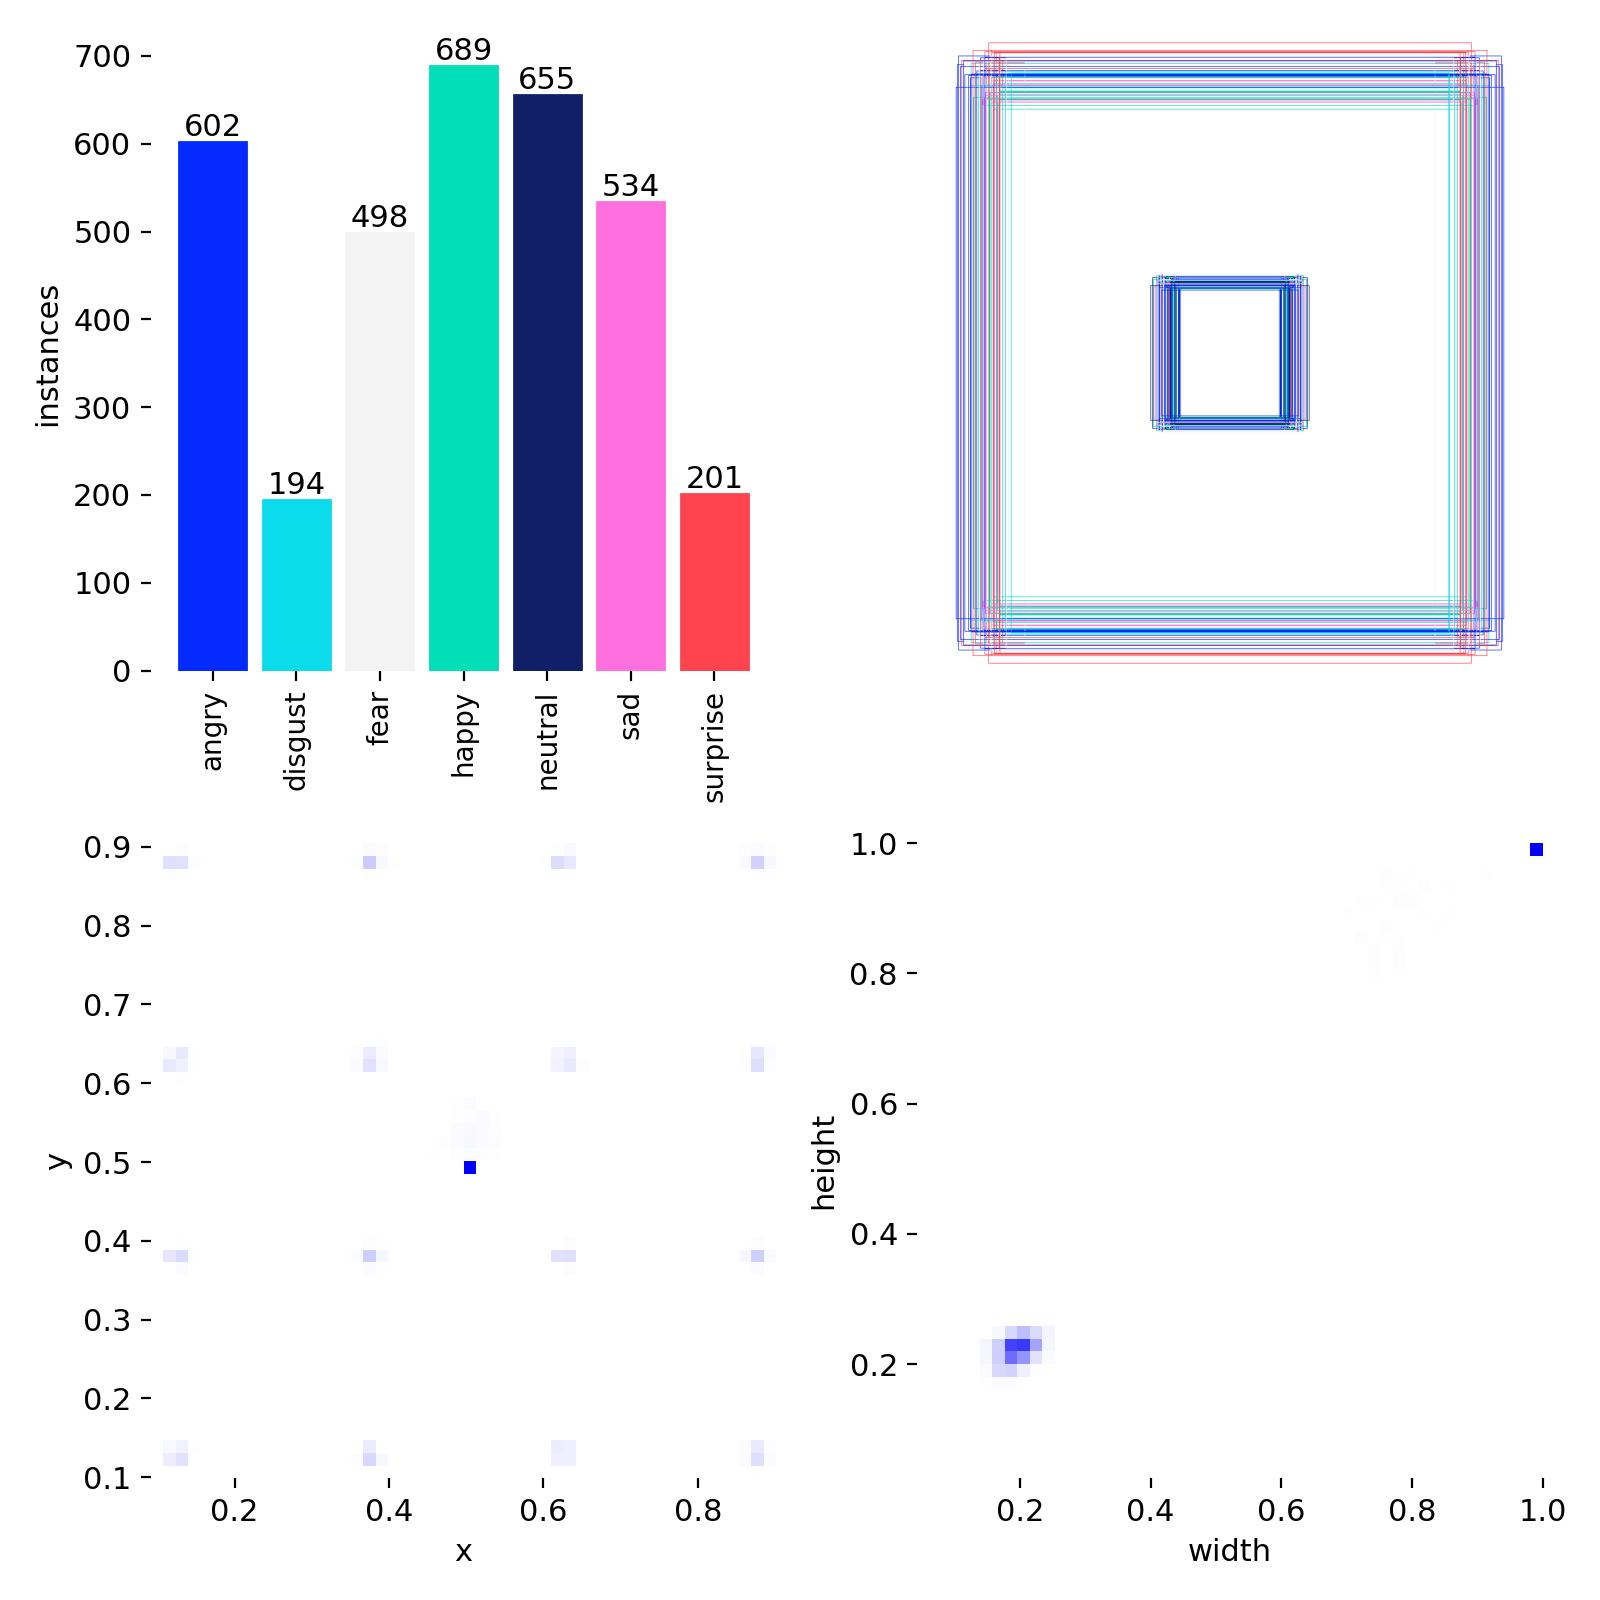

In [13]:
Image("/content/runs/detect/train2/labels.jpg", width="600")

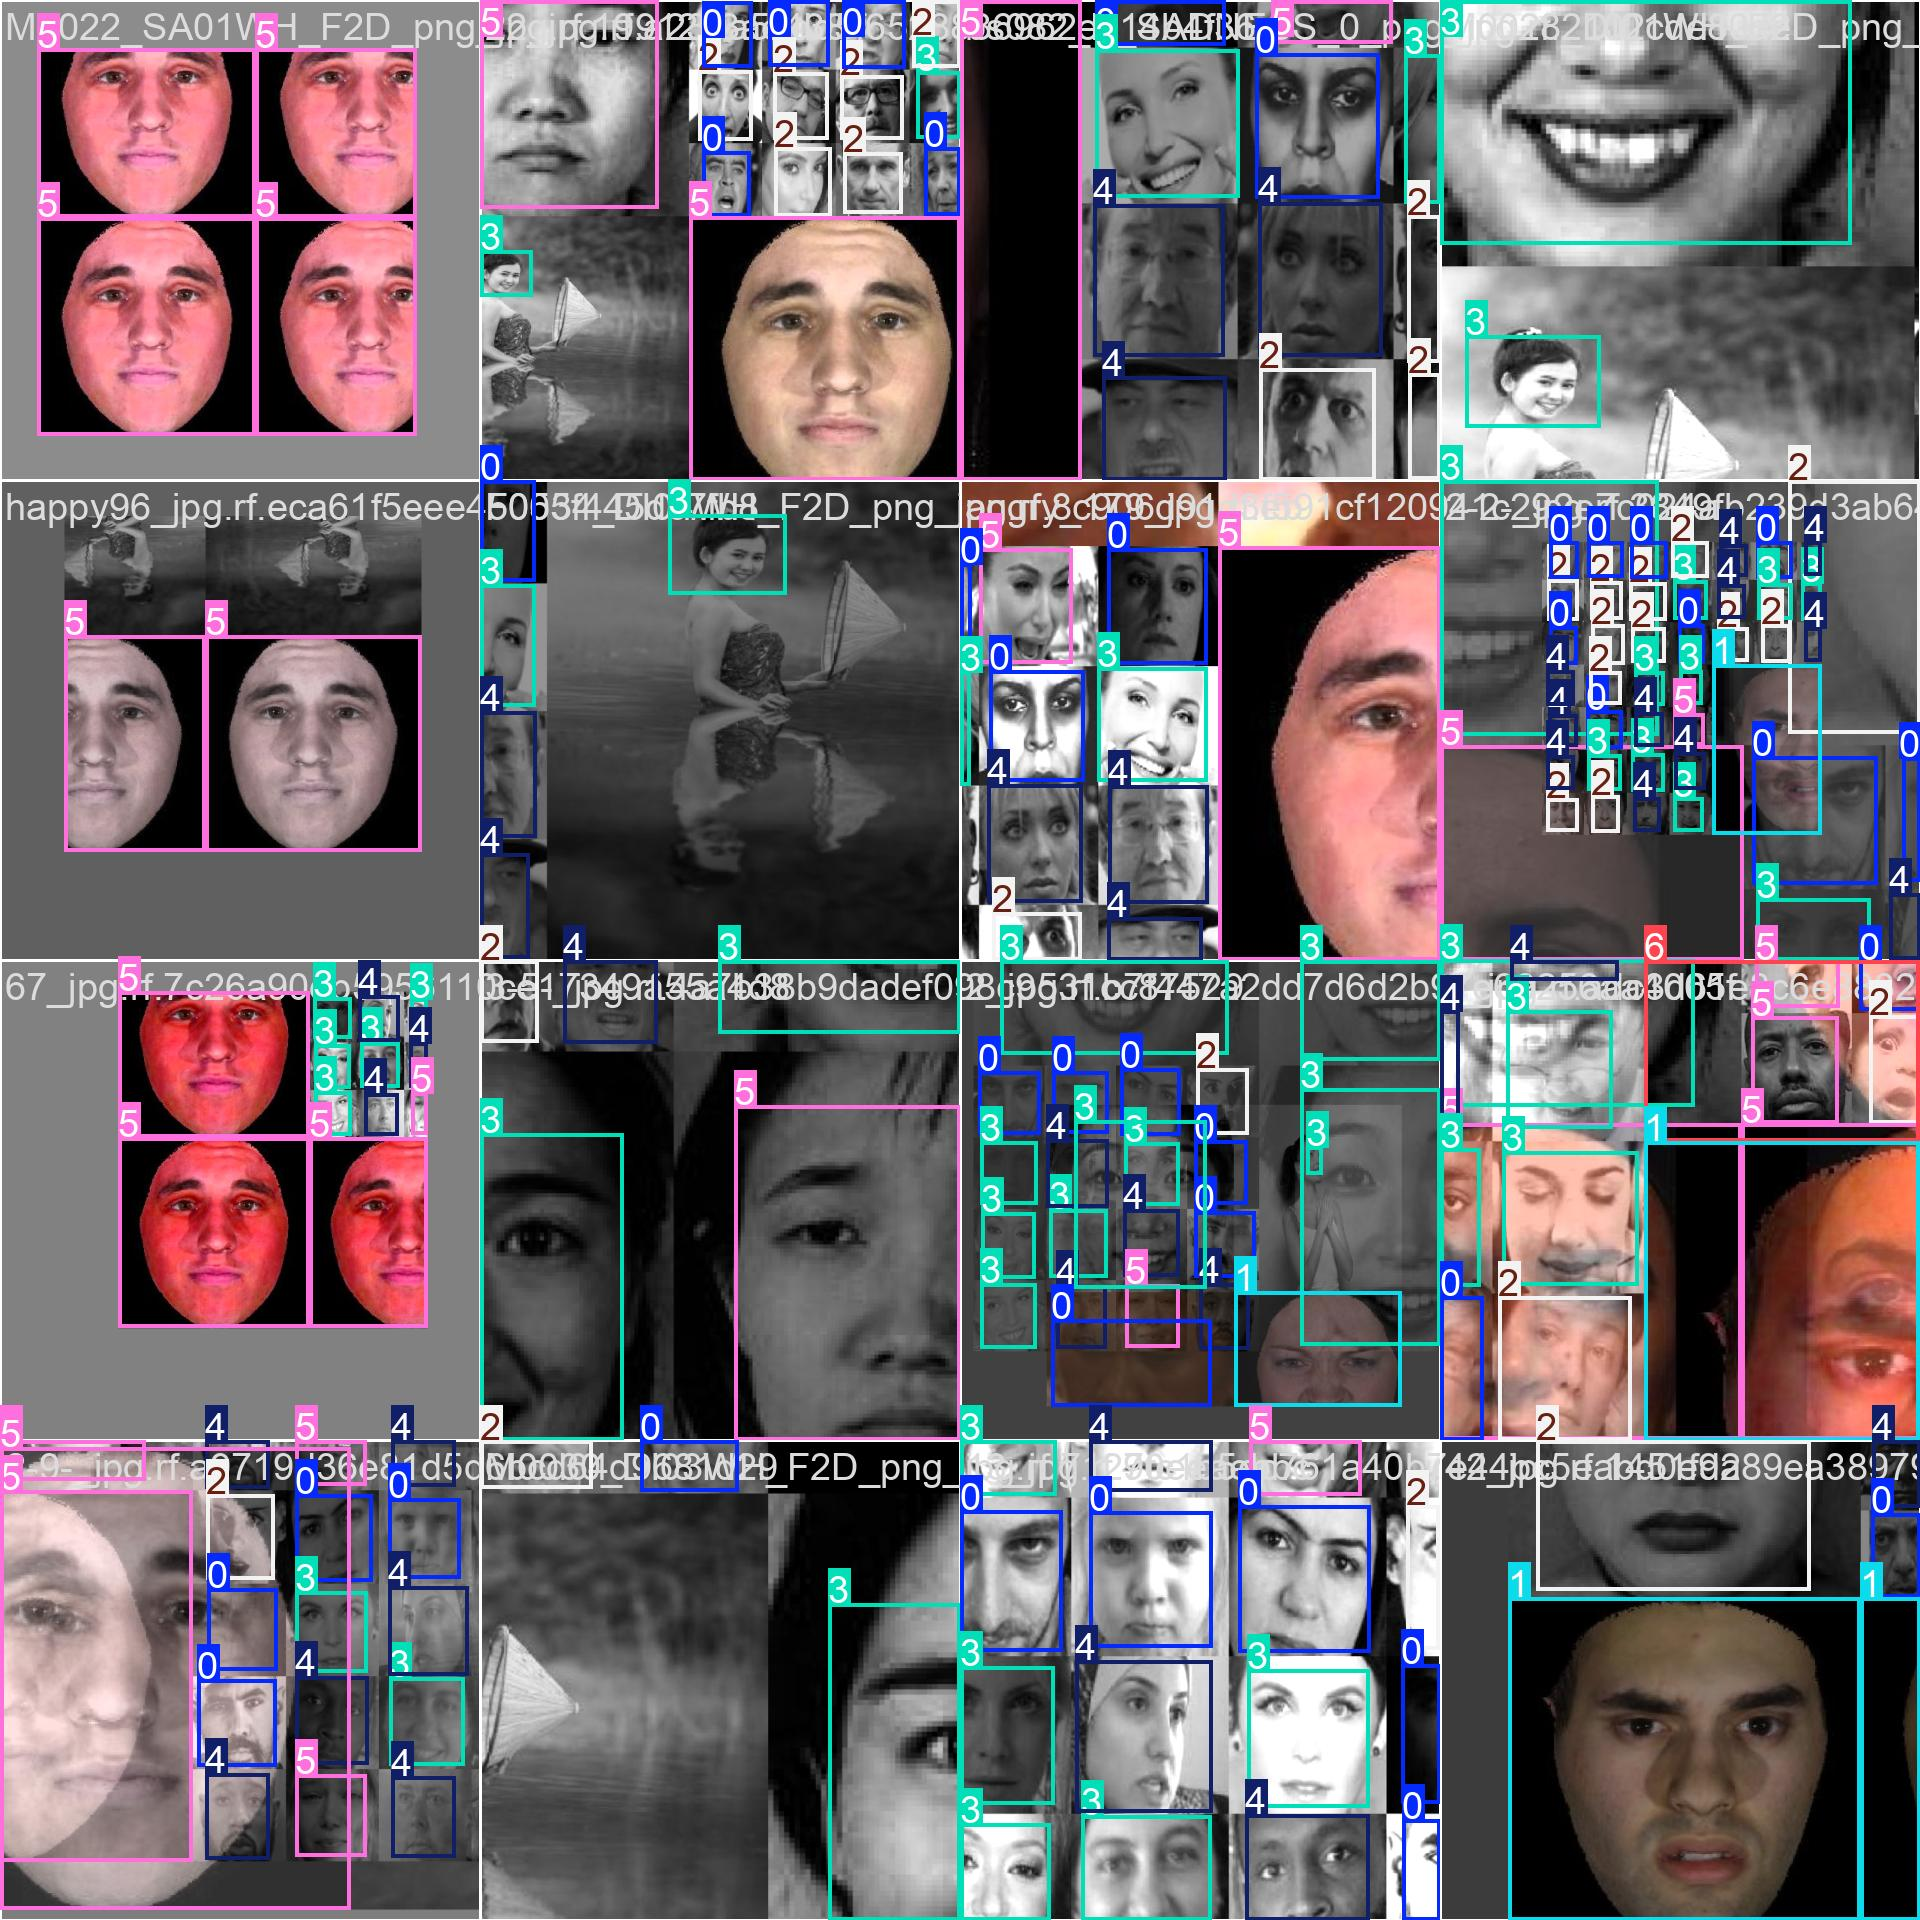

In [14]:
Image("/content/runs/detect/train2/train_batch0.jpg", width="600")

In [15]:
!yolo task=detect mode=val model=/content/runs/detect/train2/weights/best.pt data={dataset.location}/data.yaml

Ultralytics 8.3.227 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLO11m summary (fused): 125 layers, 20,035,429 parameters, 0 gradients, 67.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1597.2±172.4 MB/s, size: 36.9 KB)
val: Scanning /content/Facial-Emotion-Dataset--3/valid/labels.cache... 185 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 185/185 3.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 12/12 1.8it/s 6.6s
                   all        185        862      0.702      0.759      0.781      0.652
                 angry         76        176      0.611      0.608      0.639      0.488
               disgust         18         18      0.764      0.944      0.941      0.932
                  fear         51        128      0.639      0.727      0.747      0.576
                 happy         64        180      0.834      0.822      0.854      0.603
               neutral     

In [16]:
!yolo task=detect mode=predict model="/content/runs/detect/train2/weights/best.pt" conf=0.5 source={dataset.location}/test/images save=True

Ultralytics 8.3.227 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLO11m summary (fused): 125 layers, 20,035,429 parameters, 0 gradients, 67.7 GFLOPs

image 1/99 /content/Facial-Emotion-Dataset--3/test/images/1-5-_jpg.rf.fedd78c04d11645905c4124fa52aaa17.jpg: 640x640 1 angry, 1 disgust, 36.9ms
image 2/99 /content/Facial-Emotion-Dataset--3/test/images/1-7-_jpg.rf.e66429ccfa57cb2c03c5e06fe43e3a8b.jpg: 640x640 1 sad, 36.8ms
image 3/99 /content/Facial-Emotion-Dataset--3/test/images/1-8-_jpg.rf.d4579ef9e8b6ca750aa61bd65ff33b47.jpg: 640x640 1 happy, 36.8ms
image 4/99 /content/Facial-Emotion-Dataset--3/test/images/10_jpg.rf.ce00a096968d9ce9ceb0a85b39e601cb.jpg: 640x640 2 angrys, 1 fear, 4 happys, 4 neutrals, 3 sads, 36.8ms
image 5/99 /content/Facial-Emotion-Dataset--3/test/images/14_jpg.rf.26f69d5d4bfeffe1665b1558c11f95e9.jpg: 640x640 1 angry, 8 fears, 1 happy, 4 neutrals, 2 sads, 36.8ms
image 6/99 /content/Facial-Emotion-Dataset--3/test/images/2-3-_jpg.rf.2d5cb265aa6d734ebff

Nos decargamos el modelo

In [ ]:
from google.colab import files

files.download('/content/runs/detect/train2/weights/best.pt')